In [9]:
# Step 1 — Data Loading and Preprocessing
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
import numpy as np

(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

In [2]:
# Step 2 — Build Your Model
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
# Step 3 — Compile and Train
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train,
                    epochs=20,
                    batch_size=64,
                    validation_data=(X_test, y_test))

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 54s 65ms/step - accuracy: 0.4628 - loss: 1.4970 - val_accuracy: 0.5549 - val_loss: 1.2545
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accuracy: 0.6032 - loss: 1.1366 - val_accuracy: 0.6261 - val_loss: 1.0691
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 55ms/step - accuracy: 0.6520 - loss: 0.9969 - val_accuracy: 0.6336 - val_loss: 1.0413
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 90s 65ms/step - accuracy: 0.6850 - loss: 0.9085 - val_accuracy: 0.6638 - val_loss: 0.9640
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 61s 78ms/step - accuracy: 0.7080 - loss: 0.8401 - val_accuracy: 0.6740 - val_loss: 0.9280
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 120s 125ms/step - accuracy: 0.7288 - loss: 0.7762 - val_accuracy: 0.6914 - val_loss: 0.8900
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 109s 81ms/step - accuracy: 0.7523 - loss: 0.7140 - val_accuracy: 0.6983 - val_loss: 0.8839
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 63ms/step - accuracy: 0.7715 - loss: 0.6599

In [4]:
# Step 4 — Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print("Test accuracy:", test_acc)

313/313 - 5s - 15ms/step - accuracy: 0.6945 - loss: 1.4672
Test accuracy: 0.6945000290870667


In [5]:
# Step 5 — Experiments

# Experiment A: Add Dropout
model_dropout = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),  # Dropout added
    tf.keras.layers.Dense(10, activation='softmax')
])

model_dropout.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

history_dropout = model_dropout.fit(X_train, y_train,
                                    epochs=20,
                                    batch_size=64,
                                    validation_data=(X_test, y_test))

test_loss_d, test_acc_d = model_dropout.evaluate(X_test, y_test, verbose=2)
print("Dropout Test accuracy:", test_acc_d)


# Experiment B: Add Batch Normalization
model_bn = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_bn.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

history_bn = model_bn.fit(X_train, y_train,
                          epochs=20,
                          batch_size=64,
                          validation_data=(X_test, y_test))

test_loss_bn, test_acc_bn = model_bn.evaluate(X_test, y_test, verbose=2)
print("BatchNorm Test accuracy:", test_acc_bn)


Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 83ms/step - accuracy: 0.3915 - loss: 1.6566 - val_accuracy: 0.5405 - val_loss: 1.3041
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 55s 70ms/step - accuracy: 0.5186 - loss: 1.3428 - val_accuracy: 0.5933 - val_loss: 1.1421
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 77s 64ms/step - accuracy: 0.5697 - loss: 1.2042 - val_accuracy: 0.6304 - val_loss: 1.0424
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 64ms/step - accuracy: 0.6020 - loss: 1.1210 - val_accuracy: 0.6559 - val_loss: 0.9802
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 99s 85ms/step - accuracy: 0.6291 - loss: 1.0530 - val_accuracy: 0.6694 - val_loss: 0.9503
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 65ms/step - accuracy: 0.6459 - loss: 1.0079 - val_accuracy: 0.6729 - val_loss: 0.9260
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 87s 71ms/step - accuracy: 0.6611 - loss: 0.9662 - val_accuracy: 0.6824 - val_loss: 0.9191
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 56ms/step - accuracy: 0.6759 - loss: 0.9245 - 

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


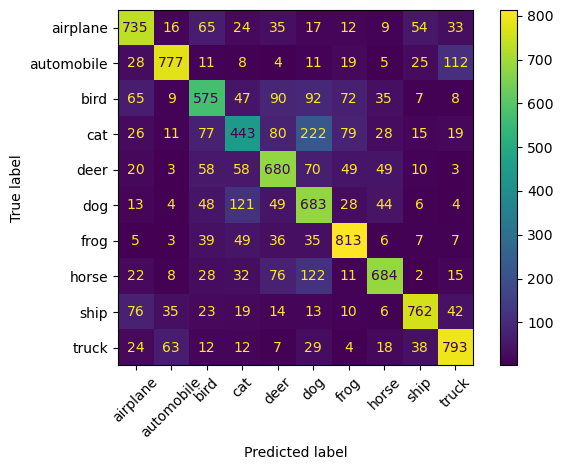

In [11]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Define CIFAR-10 class labels
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(xticks_rotation=45)
plt.tight_layout()
plt.savefig(r"C:\Users\Lenovo\ICT120_FinalProject\webapp\static\confusion_matrix.png")
plt.show()


In [12]:
# Step 6 — Save Model to webapp folder
model.save(r"C:\Users\Lenovo\ICT120_FinalProject\webapp\cifar10_model.h5")
print(" Model saved to webapp folder")

 Model saved to webapp folder


In [15]:
from sklearn.metrics import classification_report

# Run predictions on the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Overall test accuracy
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Per-class classification report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=classes))


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step 
Test Accuracy: 69.45%
Classification Report:
              precision    recall  f1-score   support

    airplane       0.72      0.73      0.73      1000
  automobile       0.84      0.78      0.81      1000
        bird       0.61      0.57      0.59      1000
         cat       0.54      0.44      0.49      1000
        deer       0.63      0.68      0.66      1000
         dog       0.53      0.68      0.60      1000
        frog       0.74      0.81      0.78      1000
       horse       0.77      0.68      0.73      1000
        ship       0.82      0.76      0.79      1000
       truck       0.77      0.79      0.78      1000

    accuracy                           0.69     10000
   macro avg       0.70      0.69      0.69     10000
weighted avg       0.70      0.69      0.69     10000




Validation Run 1
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
Validation Accuracy: 72.60%


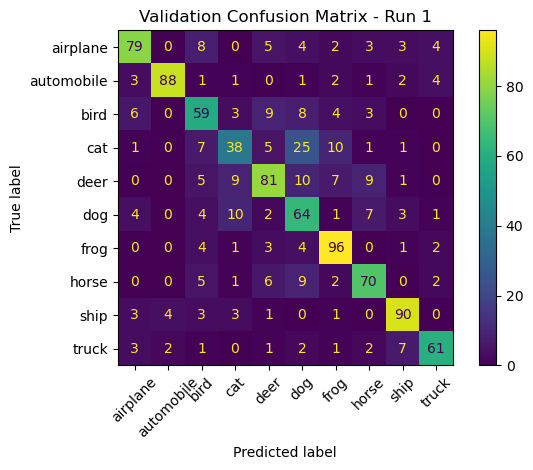


Validation Run 2
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Validation Accuracy: 70.00%


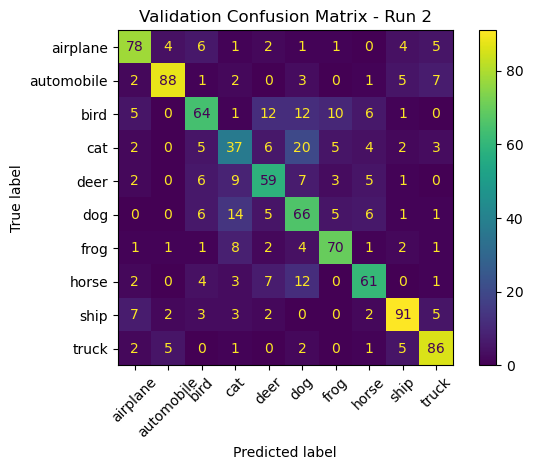


Validation Run 3
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Validation Accuracy: 67.80%


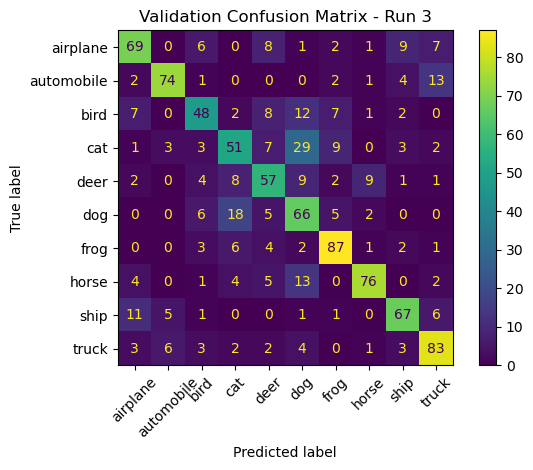


Validation Run 4
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Validation Accuracy: 70.80%


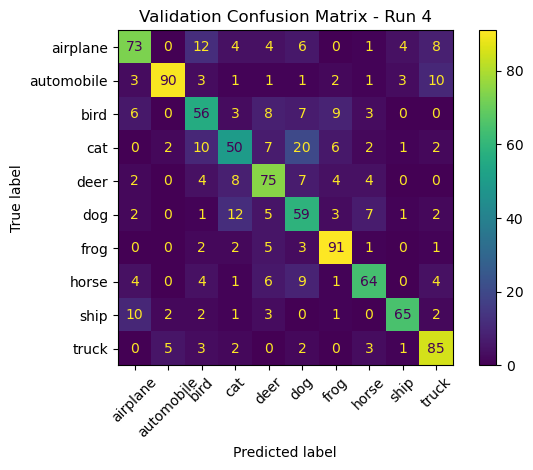


Validation Run 5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Validation Accuracy: 70.80%


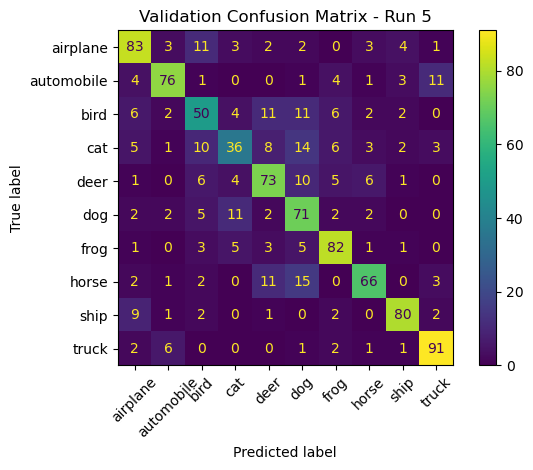


Validation Run 6
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Validation Accuracy: 66.30%


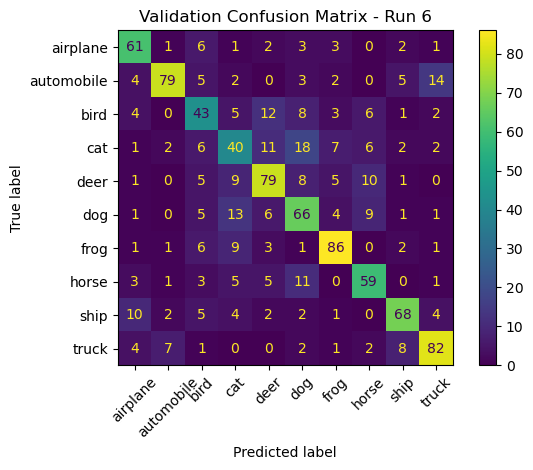


Validation Run 7
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Validation Accuracy: 69.10%


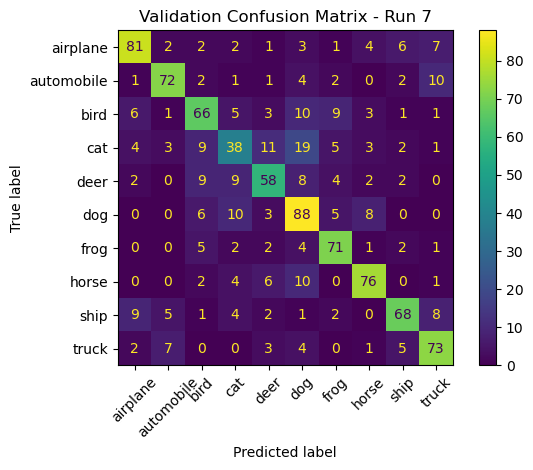


Validation Run 8
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Validation Accuracy: 68.60%


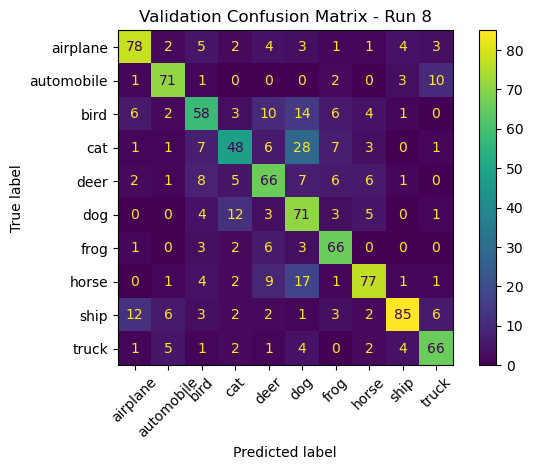


Validation Run 9
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Validation Accuracy: 70.30%


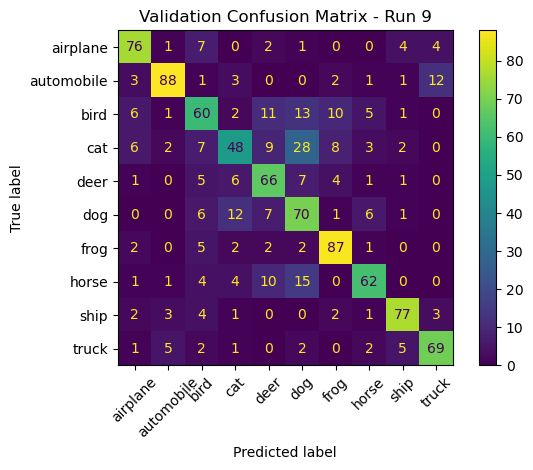


Validation Run 10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Validation Accuracy: 70.40%


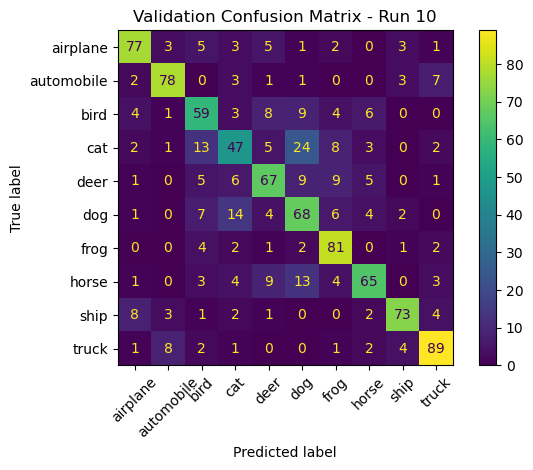

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# Run 10 validation experiments
for run in range(1, 11):
    print(f"\nValidation Run {run}")

    # Select a random subset of test data (e.g., 1000 samples)
    idx = np.random.choice(len(X_test), 1000, replace=False)
    X_val = X_test[idx]
    y_val = y_test[idx]

    # Predictions
    y_pred = model.predict(X_val)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_val, axis=1)

    # Accuracy score
    acc = accuracy_score(y_true, y_pred_classes)
    print(f"Validation Accuracy: {acc*100:.2f}%")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred_classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(xticks_rotation=45)
    plt.title(f"Validation Confusion Matrix - Run {run}")
    plt.tight_layout()
    plt.show()
